<center>
    <p style="text-align:center">
        <img alt="phoenix logo" src="https://raw.githubusercontent.com/Arize-ai/phoenix-assets/9e6101d95936f4bd4d390efc9ce646dc6937fb2d/images/socal/github-large-banner-phoenix.jpg" width="1000"/>
        <br>
        <br>
        <a href="https://arize.com/docs/phoenix/">Docs</a>
        |
        <a href="https://github.com/Arize-ai/phoenix">GitHub</a>
        |
        <a href="https://arize-ai.slack.com/join/shared_invite/zt-2w57bhem8-hq24MB6u7yE_ZF_ilOYSBw#/shared-invite/email">Community</a>
    </p>
</center>
<h1 align="center">Aligning Evals (LLM Judge)</h1>

In this tutorial, we’ll run a Mastra agent and build a custom evaluator for it. The goal is to understand the workflow for creating evaluators that align with your specific use case. We’ll be working in TypeScript.

This tutorial also introduces a human-in-the-loop step for writing annotations, which are used to benchmark and measure agent performance.

Run `deno install` then `jupyter notebook` to get this notebook up and running. This notebook assumes you have already run the Mastra agent provided and generated traces in Phoenix. 

## Setup

Let's start by importing the necessary packages.

In [ ]:
import { createClient } from "npm:@arizeai/phoenix-client@latest";
import { runExperiment, asEvaluator, evaluateExperiment } from "npm:@arizeai/phoenix-client@latest/experiments";
import { createDataset,getDataset } from "npm:@arizeai/phoenix-client@latest/datasets";
import { getSpans } from "npm:@arizeai/phoenix-client@latest/spans";
import { OpenAI } from "npm:openai";

Set up your OpenAI API key.

In [ ]:
import { createOpenAI } from 'npm:@ai-sdk/openai@latest';

const openaiApiKey = prompt("Enter your OpenAI API key:");

if (!openaiApiKey) {
  console.error('Please enter your OpenAI API key to continue');
  Deno.exit(1);
}

const openai = createOpenAI({ apiKey: openaiApiKey });
const openaiModel = openai("gpt-4.1")

> **Note:** The code below only initializes the Phoenix client. You must have the Phoenix server running separately.
> See the [deployment guide](https://arize.com/docs/phoenix/environments#terminal) for information on how to start the Phoenix server.

In [ ]:
const client = createClient();
console.log('Phoenix client initialized. Access Phoenix UI at http://localhost:6006');

## Creating a Dataset

Grab the Mastra agent traces from Phoenix and format them into dataset examples. In this example, we’ll extract the user query, the tool calls, and the agent’s final response. Once formatted, we’ll upload this dataset back into Phoenix for evaluation.

In [ ]:
const agentSpans = await getSpans({
    client: client,
    project: { projectName: "mastra-orchestrator-workflow" },
    limit: 1000
  });

console.log("Total spans fetched:", agentSpans.spans?.length || 0);

In [ ]:
// Group spans by trace ID
function groupSpansByTraceId(spans: any[]) {
  const traceGroups: { [traceId: string]: any[] } = {};
  
  spans.forEach(span => {
    const traceId = span.context?.trace_id || span.traceId || 'unknown';
    
    if (!traceGroups[traceId]) {
      traceGroups[traceId] = [];
    }
    
    traceGroups[traceId].push(span);
  });
  
  return traceGroups;
}

// Group the spans
const groupedSpans = groupSpansByTraceId(agentSpans.spans || []);
const traceIds = Object.keys(groupedSpans);

console.log(`\n📊 Found ${traceIds.length} unique traces`);
console.log("Trace IDs:", traceIds.slice(0, 5)); // Show first 5 trace IDs

In [ ]:
// Analyze each trace and show span grouping
const traceAnalysis = traceIds.map(traceId => {
  const spans = groupedSpans[traceId];
  const sortedSpans = spans.sort((a, b) => a.start_time - b.start_time);
  
  const startTime = Math.min(...spans.map(s => s.start_time || 0));
  const endTime = Math.max(...spans.map(s => s.end_time || 0));
  const duration = endTime - startTime;
  
  return {
    traceId,
    spanCount: spans.length,
    duration: duration,
    startTime: startTime > 0 ? new Date(startTime).toISOString() : 'unknown',
    endTime: endTime > 0 ? new Date(endTime).toISOString() : 'unknown',
    spans: sortedSpans.map(span => ({
      spanId: span.span_id || span.id,
      name: span.name,
      duration: span.end_time - span.start_time,
      attributes: span.attributes || {}
    }))
  };
});

console.log("\n🔍 Trace Analysis:");


// Show the grouped spans structure
console.log("\n📋 Grouped Spans Structure:");
console.log("Total traces:", traceIds.length);

// Create dataset examples with user query as input and ai.toolCall spans as output
const datasetExamples = traceAnalysis.map(trace => {
  // Extract user query from first span's input.value
  const userQuery = trace.spans[0]?.attributes?.['input.value'] || 'User query not found';
  
  // Extract agent response from first span's output.value
  const agentResponse = trace.spans[0]?.attributes?.['output.value'] || 'Agent response not found';
  
  // Filter spans where name = "ai.toolCall"
  const aiToolCallSpans = trace.spans.filter(span => span.name === 'ai.toolCall');
  
  return {
    input: {
      userQuery
    },
    output: {
      agentResponse: agentResponse,
      aiToolCallCount: aiToolCallSpans.length,
      aiToolCallSpans: aiToolCallSpans.map(span => ({
        spanId: span.spanId,
        name: span.name,
        duration: span.duration || 0,
        attributes: span.attributes
      }))
    },
    metadata: {
      traceId: trace.traceId,
      source: 'mastra-orchestrator-workflow',
      timestamp: trace.startTime
    }
  };
});

console.log(`Prepared ${datasetExamples.length} examples for dataset`);

const { datasetId } = await createDataset({
  name: `mastra-orchestrator-traces-${Date.now()}`,
  description: "Traces from Mastra orchestrator workflow",
  examples: datasetExamples
});

const dataset = await getDataset({ dataset: { datasetId } });

# Annotations

Next, we need human annotations to serve as ground truth for evaluation. To do this, we’ll add an annotation field in the metadata of each dataset example. This way, every example includes a reference label that our evaluator outputs can be compared against.

In this example, we’ll evaluate how well the agent’s final response aligns with the tool calls and their outputs. We’ll use three labels for evaluation: aligned, partially_aligned, and misaligned.

You can adapt this setup to other evaluation criteria as needed.
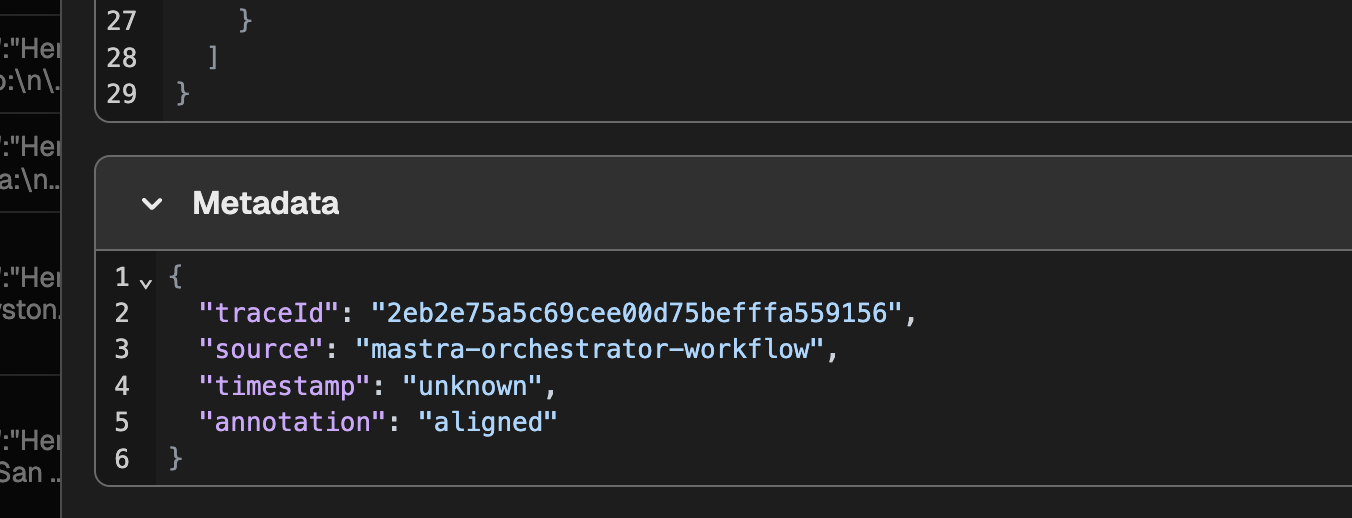. 

# LLM Judge Improvement Cycle

Now we’ll start with a basic evaluation prompt and improve it iteratively. The workflow looks like this:

**Run the evaluator --> Inspect the outputs and experiment results --> Update the evaluation prompt based on what’s lacking --> Repeat until performance improves**

We’ll use Phoenix experiments to identify weaknesses in the evaluator, review explanations, and track performance changes over time.

In this notebook, we’ll go through two improvement cycles, but you can extend this process with more iterations to fine-tune the evaluator further.

In [ ]:
const evalPromptTemplateV1 = `
You are evaluating whether the agent's final response matches the tool outputs.

DATA:
- Query: {{query}}
- Tool Outputs & Response: {{data}}

Choose one label:
- "aligned"
- "partially_aligned"
- "misaligned"

Output only the label.
`;

In [ ]:
import { type RunExperimentParams } from "npm:@arizeai/phoenix-client/experiments";
import { createClassificationEvaluator } from "npm:@arizeai/phoenix-evals@latest";

const task: RunExperimentParams["task"] = async (example) => {
    const query = example.input.userQuery;
    const agentData = JSON.stringify(example.output, null, 2); // format tool outputs nicely
    
    const evaluator = await createClassificationEvaluator({
        model: openaiModel,
        choices: { aligned: 1, misaligned: 0, partially_aligned: 0.5 },
        promptTemplate: evalPromptTemplateV1,
    });

    const result = await evaluator.evaluate({
    query: query,
    data: agentData,
    });

    console.log({
        exampleId: example.id,
        query,
        label: result.label,
        score: result.score,
        explanation: result.explanation,
     });
  
  return result;
};

In [ ]:
const matchesAnnotation = asEvaluator({
  name: "matches_annotation",
  kind: "CODE",
  evaluate: async ({ metadata, output }) => {
    const annotation = metadata.annotation;
    const evalLabel = output.label;

    const isMatch = annotation === evalLabel;

    return {
      score: isMatch ? 1.0 : 0.0,
      label: isMatch ? "match" : "mismatch",
      metadata: { annotation, evalLabel },
      explanation: isMatch
        ? `The output label matches the annotation ("${annotation}").`
        : `The output label ("${evalLabel}") does not match the annotation ("${annotation}").`
    };
  }
});


In [ ]:
const experiment = await runExperiment({
  client,
  experimentName: "evalTemplateV1",
  dataset: {datasetId: datasetId},
  task,
  evaluators: [matchesAnnotation],
  logger: console,
});

In [ ]:
const evalPromptTemplateV2 = `
You are evaluating how well an agent's FINAL RESPONSE aligns with the TOOL OUTPUTS it used.

You will be given:
- The original user query
- The agent’s final response
- The tool outputs produced by the agent

QUERY:
{{query}}

TOOL + RESPONSE DATA:
{{data}}

Choose exactly ONE label:

- "aligned" → The final response is fully supported by the tool outputs.
  * Every piece of information in the response can be traced back to the tool calls.
  * There are no additions, fabrications, or contradictions.

- "partially_aligned" → The final response mixes correct tool-based information with extra or inconsistent details.
  * Some information in the response comes from tool outputs, but other parts are missing, fabricated, or inconsistent.
  * The response is only partially grounded in the tool calls.

- "misaligned" → The final response ignores, contradicts, or invents information unrelated to the tool outputs.
  * The tool outputs do not support the response at all, or the response is in direct conflict with them.

Guidelines:
- Focus strictly on whether the content in the final response is supported by the tool outputs.
- Do not reward fluent language or style; only check alignment.
- Provide a short explanation justifying the label.

Your output must contain only one of these labels:
aligned, partially_aligned, or misaligned.
`;

In [ ]:
const task: RunExperimentParams["task"] = async (example) => {
    const query = example.input.userQuery;
    const agentData = JSON.stringify(example.output, null, 2); // format tool outputs nicely
    
    const evaluator = await createClassificationEvaluator({
        model: openaiModel,
        choices: { aligned: 1, misaligned: 0, partially_aligned: 0.5 },
        promptTemplate: evalPromptTemplateV2,
    });

    const result = await evaluator.evaluate({
    query: query,
    data: agentData,
    });

    console.log({
        exampleId: example.id,
        query,
        label: result.label,
        score: result.score,
        explanation: result.explanation,
     });
  
  return result;
};

In [ ]:
const experiment = await runExperiment({
  client,
  experimentName: "evalTemplateV2",
  dataset: {datasetId: datasetId},
  task,
  evaluators: [matchesAnnotation],
  logger: console,
});

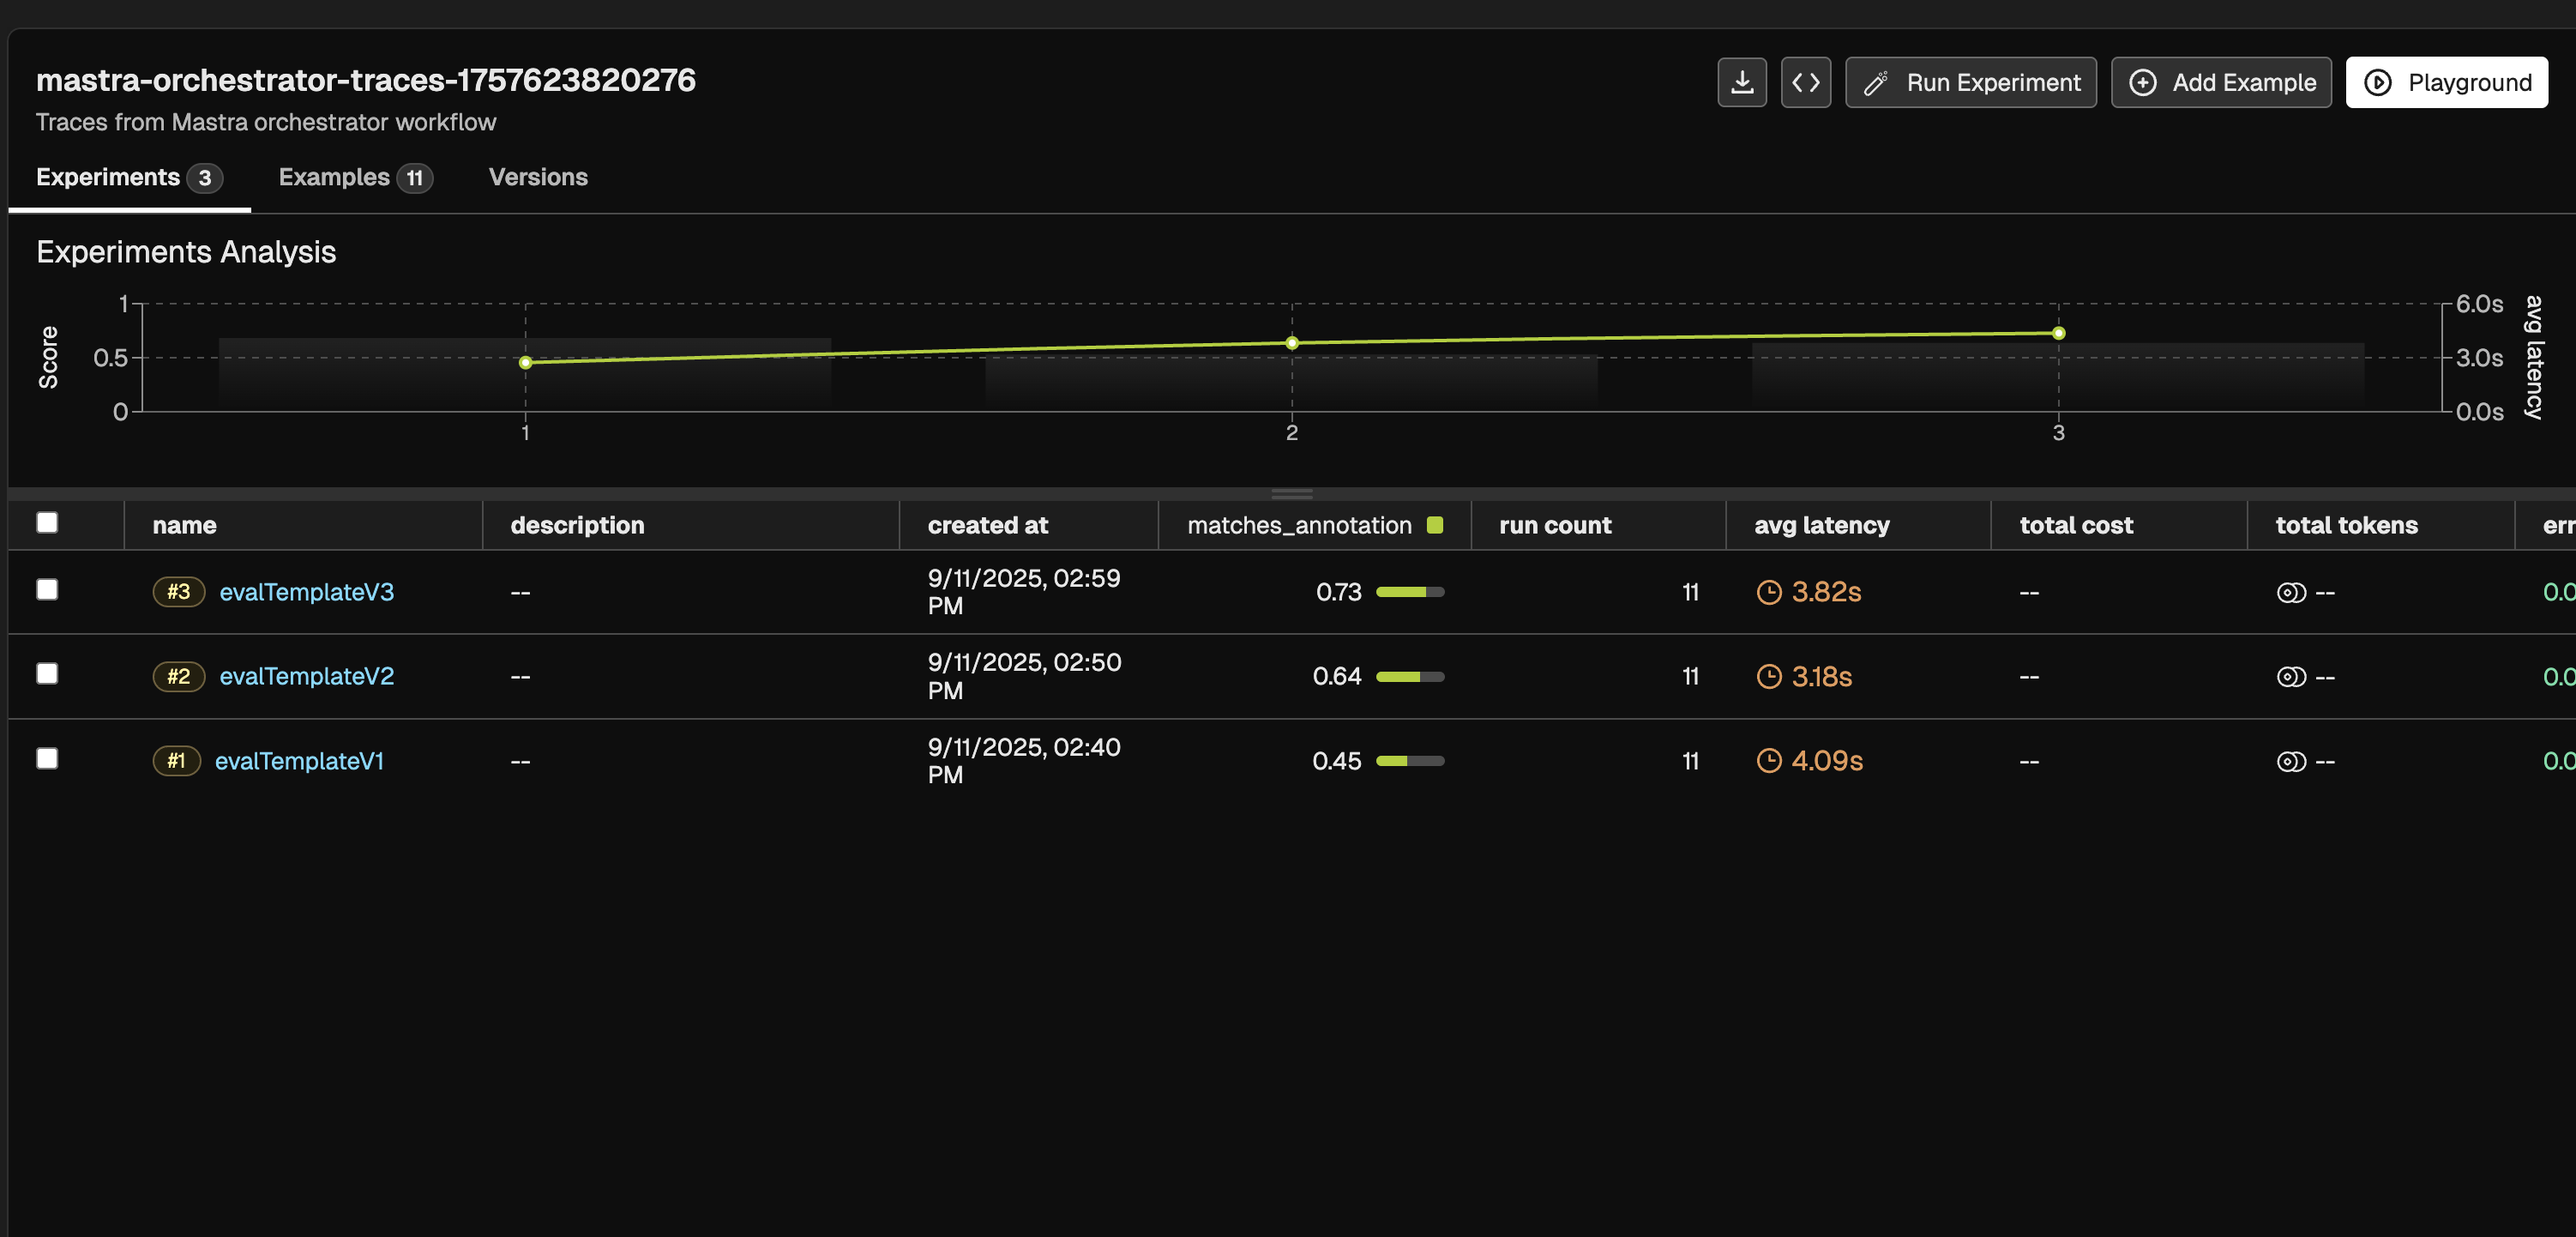